# Time Series Analysis on Air Passengers Dataset
---
This notebook demonstrates **AR, MA, ARMA, ARIMA, and SARIMA** models on the famous Air Passengers dataset.
We will go step by step:
- Load & visualize data
- Check stationarity
- Apply AR, MA, ARMA
- Apply ARIMA & SARIMA
- Forecast future values


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX


In [2]:
# Load AirPassengers dataset
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df = pd.read_csv(url, parse_dates=['Month'], index_col='Month')

In [3]:
df

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


In [4]:
df.head(50)

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
1949-06-01,135
1949-07-01,148
1949-08-01,148
1949-09-01,136


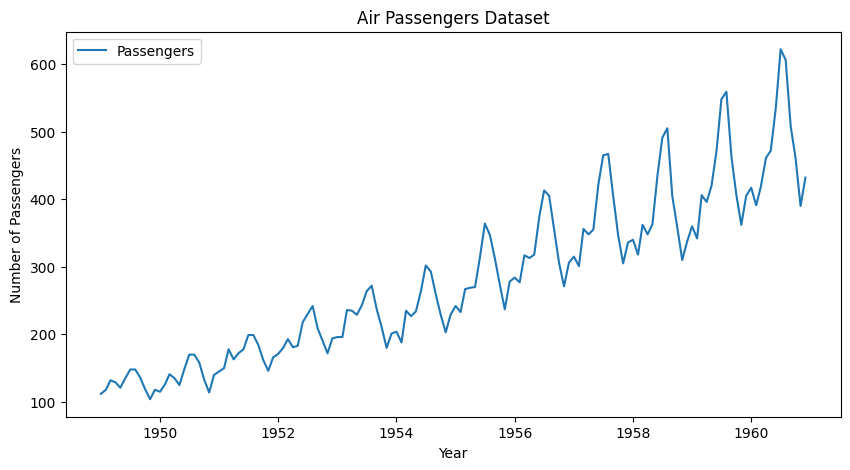

In [6]:
plt.figure(figsize=(10,5))
plt.plot(df, label='Passengers') # Gives a name to the plotted line.
plt.title('Air Passengers Dataset')
plt.xlabel('Year')
plt.ylabel('Number of Passengers')
plt.legend() # Passengers label is displayed
plt.show()


In [7]:
# Augmented Dickey-Fuller Test
result = adfuller(df['Passengers'])
print('p-value:', result[1])

if result[1] > 0.05:
    print("Series is Non-Stationary")
else:
    print("Series is Stationary")

p-value: 0.991880243437641
Series is Non-Stationary


In [8]:
# Differencing to make stationary
df_diff = df['Passengers'].diff().dropna()
df_diff

Month
1949-02-01     6.0
1949-03-01    14.0
1949-04-01    -3.0
1949-05-01    -8.0
1949-06-01    14.0
              ... 
1960-08-01   -16.0
1960-09-01   -98.0
1960-10-01   -47.0
1960-11-01   -71.0
1960-12-01    42.0
Name: Passengers, Length: 143, dtype: float64

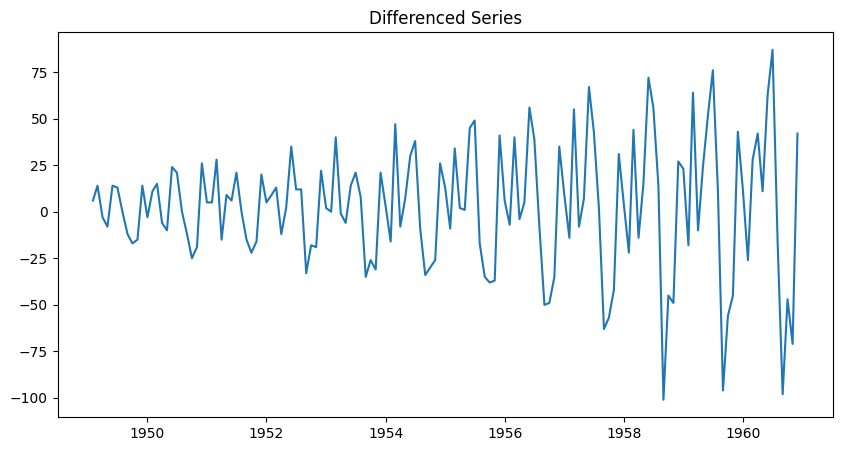

In [9]:
plt.figure(figsize=(10,5))
plt.plot(df_diff)
plt.title('Differenced Series')
plt.show()

In [10]:
# Check stationarity again
result_diff = adfuller(df_diff)
print('p-value (Diff):', result_diff[1])

p-value (Diff): 0.05421329028382671


## AutoRegression (AR) Model

In [18]:
len(df)

144

In [11]:
train = df['Passengers'][:100]
test = df['Passengers'][100:]

ar_model = AutoReg(train, lags=12).fit()
ar_pred = ar_model.predict(start=len(train), end=len(train)+len(test)-1)


c:\Users\Datamites\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Datamites\anaconda3\Lib\site-packages\statsmodels\tsa\deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


In [14]:
train

Month
1949-01-01    112
1949-02-01    118
1949-03-01    132
1949-04-01    129
1949-05-01    121
             ... 
1956-12-01    306
1957-01-01    315
1957-02-01    301
1957-03-01    356
1957-04-01    348
Name: Passengers, Length: 100, dtype: int64

In [15]:
test

Month
1957-05-01    355
1957-06-01    422
1957-07-01    465
1957-08-01    467
1957-09-01    404
1957-10-01    347
1957-11-01    305
1957-12-01    336
1958-01-01    340
1958-02-01    318
1958-03-01    362
1958-04-01    348
1958-05-01    363
1958-06-01    435
1958-07-01    491
1958-08-01    505
1958-09-01    404
1958-10-01    359
1958-11-01    310
1958-12-01    337
1959-01-01    360
1959-02-01    342
1959-03-01    406
1959-04-01    396
1959-05-01    420
1959-06-01    472
1959-07-01    548
1959-08-01    559
1959-09-01    463
1959-10-01    407
1959-11-01    362
1959-12-01    405
1960-01-01    417
1960-02-01    391
1960-03-01    419
1960-04-01    461
1960-05-01    472
1960-06-01    535
1960-07-01    622
1960-08-01    606
1960-09-01    508
1960-10-01    461
1960-11-01    390
1960-12-01    432
Name: Passengers, dtype: int64

In [16]:
len(train)

100

In [17]:
len(test)

44

In [13]:
ar_pred

1957-05-01    364.558647
1957-06-01    428.269849
1957-07-01    466.094410
1957-08-01    462.779662
1957-09-01    417.507252
1957-10-01    357.165161
1957-11-01    315.305136
1957-12-01    345.678406
1958-01-01    351.007631
1958-02-01    348.464125
1958-03-01    388.966506
1958-04-01    391.955933
1958-05-01    419.916110
1958-06-01    486.526898
1958-07-01    529.665849
1958-08-01    528.729238
1958-09-01    487.450807
1958-10-01    416.623386
1958-11-01    369.484398
1958-12-01    389.699784
1959-01-01    393.847807
1959-02-01    397.457379
1959-03-01    429.251760
1959-04-01    440.437729
1959-05-01    479.343040
1959-06-01    552.616692
1959-07-01    602.019805
1959-08-01    605.645968
1959-09-01    565.518251
1959-10-01    486.716156
1959-11-01    432.964891
1959-12-01    441.020722
1960-01-01    443.189817
1960-02-01    449.757932
1960-03-01    476.156532
1960-04-01    494.133392
1960-05-01    544.037946
1960-06-01    626.591947
1960-07-01    684.384006
1960-08-01    694.310902


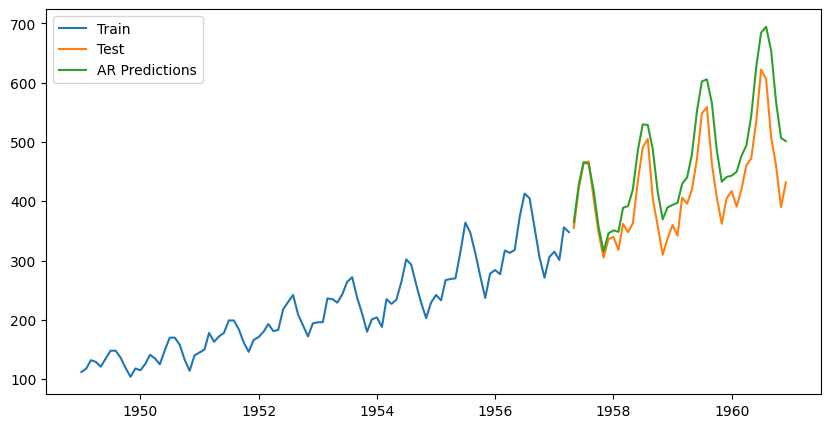

In [19]:
plt.figure(figsize=(10,5))
plt.plot(train, label='Train')
plt.plot(test, label='Test')
plt.plot(ar_pred, label='AR Predictions')
plt.legend()
plt.show()

## ARIMA Model

In [20]:
arima_model = ARIMA(train, order=(2,1,2))
arima_res = arima_model.fit()
arima_pred = arima_res.predict(start=len(train), end=len(train)+len(test)-1, typ='levels')
# Convert the predictions back to the original scale (levels).


c:\Users\Datamites\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Datamites\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Datamites\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Datamites\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['typ']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


In [22]:
arima_pred

1957-05-01    326.745451
1957-06-01    332.367349
1957-07-01    328.516093
1957-08-01    328.951850
1957-09-01    328.110296
1957-10-01    328.010184
1957-11-01    327.778133
1957-12-01    327.696251
1958-01-01    327.618883
1958-02-01    327.579631
1958-03-01    327.550889
1958-04-01    327.534130
1958-05-01    327.522916
1958-06-01    327.516021
1958-07-01    327.511558
1958-08-01    327.508759
1958-09-01    327.506969
1958-10-01    327.505838
1958-11-01    327.505118
1958-12-01    327.504662
1959-01-01    327.504372
1959-02-01    327.504188
1959-03-01    327.504071
1959-04-01    327.503997
1959-05-01    327.503950
1959-06-01    327.503920
1959-07-01    327.503901
1959-08-01    327.503889
1959-09-01    327.503882
1959-10-01    327.503877
1959-11-01    327.503874
1959-12-01    327.503872
1960-01-01    327.503871
1960-02-01    327.503870
1960-03-01    327.503869
1960-04-01    327.503869
1960-05-01    327.503869
1960-06-01    327.503869
1960-07-01    327.503869
1960-08-01    327.503869


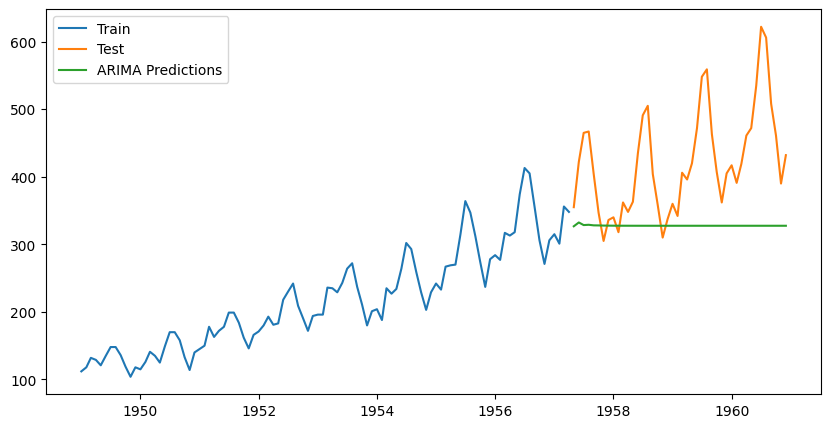

In [21]:

plt.figure(figsize=(10,5))
plt.plot(train, label='Train')
plt.plot(test, label='Test')
plt.plot(arima_pred, label='ARIMA Predictions')
plt.legend()
plt.show()

## SARIMA Model

In [23]:
sarima_model = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,12))
sarima_res = sarima_model.fit(disp=False)
sarima_pred = sarima_res.predict(start=len(train), end=len(train)+len(test)-1, typ='levels')

c:\Users\Datamites\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Datamites\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
c:\Users\Datamites\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['typ']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


In [25]:
sarima_pred

1957-05-01    354.864961
1957-06-01    407.131040
1957-07-01    449.359188
1957-08-01    438.788743
1957-09-01    392.226699
1957-10-01    345.145078
1957-11-01    309.685900
1957-12-01    346.071269
1958-01-01    354.379571
1958-02-01    341.812272
1958-03-01    393.855055
1958-04-01    386.559401
1958-05-01    393.119039
1958-06-01    446.307216
1958-07-01    487.703106
1958-08-01    477.810973
1958-09-01    430.306002
1958-10-01    382.664281
1958-11-01    347.345566
1958-12-01    383.332785
1959-01-01    391.840539
1959-02-01    378.865781
1959-03-01    431.746200
1959-04-01    424.250529
1959-05-01    430.897014
1959-06-01    483.824135
1959-07-01    525.455555
1959-08-01    515.371499
1959-09-01    468.133234
1959-10-01    420.649857
1959-11-01    385.291446
1959-12-01    421.391239
1960-01-01    429.842601
1960-02-01    416.983058
1960-03-01    469.626616
1960-04-01    462.187503
1960-05-01    468.809430
1960-06-01    521.810372
1960-07-01    563.375189
1960-08-01    553.345405


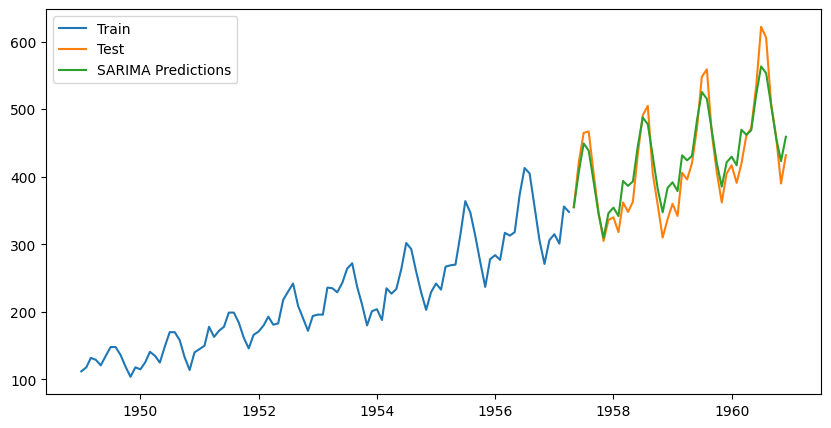

In [24]:
plt.figure(figsize=(10,5))
plt.plot(train, label='Train')
plt.plot(test, label='Test')
plt.plot(sarima_pred, label='SARIMA Predictions')
plt.legend()
plt.show()

## Future Forecasting with SARIMA

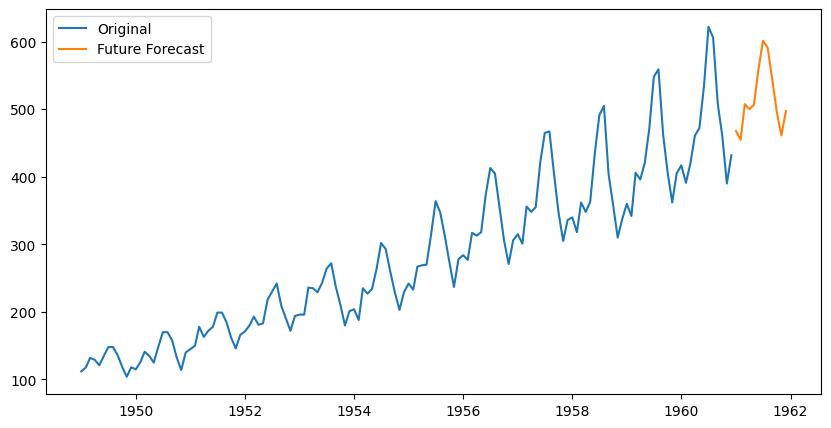

In [ ]:
future_forecast = sarima_res.predict(start=len(df), end=len(df)+25)
plt.figure(figsize=(10,5))
plt.plot(df['Passengers'], label='Original')
plt.plot(future_forecast, label='Future Forecast')
plt.legend()
plt.show()


In [38]:
df

,Passengers
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


In [45]:
future_forecast

1961-01-01    467.691650
1961-02-01    454.799527
1961-03-01    507.510064
1961-04-01    500.054957
1961-05-01    506.683829
1961-06-01    559.663896
1961-07-01    601.247547
1961-08-01    591.202416
1961-09-01    543.910059
1961-10-01    496.394567
1961-11-01    461.044207
1961-12-01    497.121169
Freq: MS, Name: predicted_mean, dtype: float64